In [1]:
import torch as t
from utils import DataManager
import random
import matplotlib.pyplot as plt
import random
from probes import LRProbe, MMProbe, CCSProbe
import configparser
import json

In [2]:
seed = random.randint(0, 10000)

In [3]:
# hyperparameters
model = 'llama-3.1-8B-Instruct'
split = 0.8
device = 'cuda:0' if t.cuda.is_available() else 'cpu'

config = configparser.ConfigParser()
config.read('config.ini')
layer = eval(config[model]['probe_layer'])
noperiod = eval(config[model]['noperiod'])

In [5]:
train_medlies  = [
    ['cities'],
    ['cities', 'neg_cities'],
    ['larger_than'],
    ['larger_than', 'smaller_than'],
    # ['likely']
]
def to_str(l):
    return '+'.join(l)

In [6]:
MODELS = [
    'llama-3.1-8B',
    'llama-3.1-8B-Instruct'
]
ProbeClasses = [
    LRProbe, 
    MMProbe,
    ]

probe_directions = {m: {str(probe_class) : {to_str(train_medley) : None for train_medley in train_medlies} for probe_class in ProbeClasses} for m in MODELS}
for m in MODELS:
    for ProbeClass in ProbeClasses:
        for medley in train_medlies:

            # set up data
            dm = DataManager()
            for dataset in medley:
                dm.add_dataset(dataset, m, layer, split=split, seed=seed, noperiod=noperiod, center=True, device=device)

            train_acts, train_labels = dm.get('train')
            probe = ProbeClass.from_data(train_acts, train_labels, device=device)
            direction = probe.direction
            probe_directions[m][str(ProbeClass)][to_str(medley)] = direction

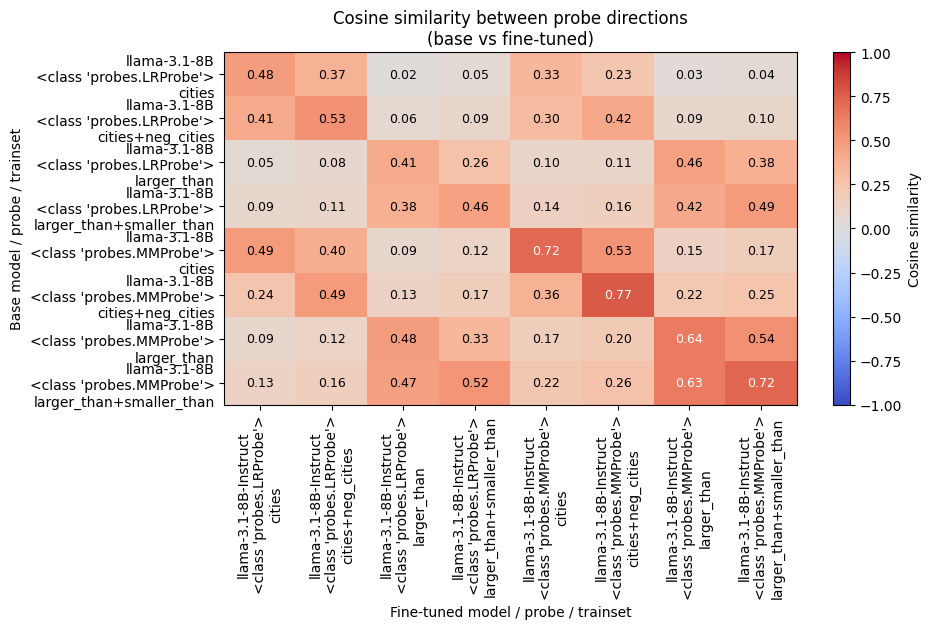

In [11]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
base_model = "llama-3.1-8B"
ft_model   = "llama-3.1-8B-Instruct"

# -----------------------------
# FLATTEN DIRECTIONS
# -----------------------------
rows = []

for model, probe_dict in probe_directions.items():
    for probe_name, medley_dict in probe_dict.items():
        for trainset, direction in medley_dict.items():
            if direction is None:
                continue
            direction = direction.detach().cpu()
            direction = direction / direction.norm()
            rows.append({
                "model": model,
                "probe": probe_name,
                "trainset": trainset,
                "direction": direction,
            })

df = pd.DataFrame(rows)

df_base = df[df.model == base_model].reset_index(drop=True)
df_ft   = df[df.model == ft_model].reset_index(drop=True)

# -----------------------------
# BUILD COSINE SIM MATRIX
# -----------------------------
y_labels = [
    f"{r.model}\n{r.probe}\n{r.trainset}"
    for r in df_base.itertuples()
]
x_labels = [
    f"{r.model}\n{r.probe}\n{r.trainset}"
    for r in df_ft.itertuples()
]

sim = np.zeros((len(df_base), len(df_ft)))

for i, b in enumerate(df_base.itertuples()):
    for j, f in enumerate(df_ft.itertuples()):
        sim[i, j] = torch.dot(b.direction, f.direction).item()

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(
    figsize=(1.2 * len(x_labels), 0.8 * len(y_labels))
)

im = ax.imshow(
    sim,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

# Axis labels
ax.set_xticks(range(len(x_labels)))
ax.set_yticks(range(len(y_labels)))
ax.set_xticklabels(x_labels, rotation=90)
ax.set_yticklabels(y_labels)

ax.set_xlabel("Fine-tuned model / probe / trainset")
ax.set_ylabel("Base model / probe / trainset")
ax.set_title("Cosine similarity between probe directions\n(base vs fine-tuned)")

# -----------------------------
# ADD NUMERIC ANNOTATIONS
# -----------------------------
for i in range(sim.shape[0]):
    for j in range(sim.shape[1]):
        val = sim[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="black" if abs(val) < 0.6 else "white",
            fontsize=9,
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()
plt.show()


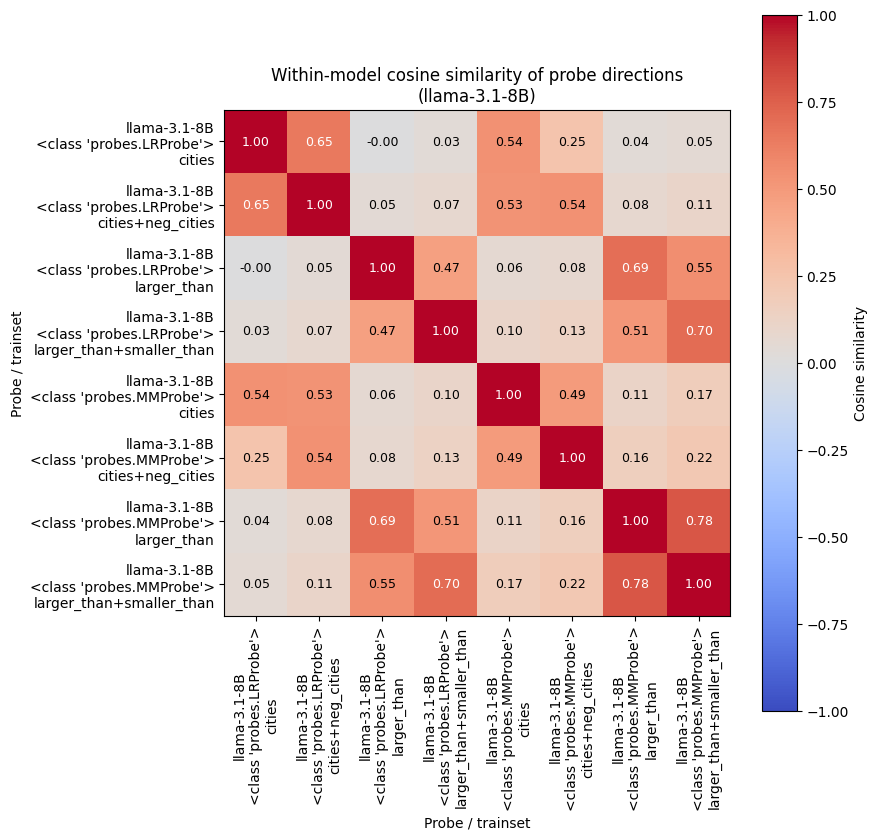

In [14]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
model_name = "llama-3.1-8B"

# -----------------------------
# FLATTEN DIRECTIONS (ONE MODEL)
# -----------------------------
rows = []

for probe_name, medley_dict in probe_directions[model_name].items():
    for trainset, direction in medley_dict.items():
        if direction is None:
            continue
        direction = direction.detach().cpu()
        direction = direction / direction.norm()
        rows.append({
            "probe": probe_name,
            "trainset": trainset,
            "direction": direction,
        })

df = pd.DataFrame(rows).reset_index(drop=True)

labels = [
    f"{model_name}\n{r.probe}\n{r.trainset}"
    for r in df.itertuples()
]

# -----------------------------
# BUILD COSINE SIM MATRIX
# -----------------------------
N = len(df)
sim = np.zeros((N, N))

for i, a in enumerate(df.itertuples()):
    for j, b in enumerate(df.itertuples()):
        sim[i, j] = torch.dot(a.direction, b.direction).item()

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(
    figsize=(1.1 * N, 1.1 * N)
)

im = ax.imshow(
    sim,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="equal",
)

# Axis labels
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_xlabel("Probe / trainset")
ax.set_ylabel("Probe / trainset")
ax.set_title(f"Within-model cosine similarity of probe directions\n({model_name})")

# -----------------------------
# ADD NUMERIC ANNOTATIONS
# -----------------------------
for i in range(N):
    for j in range(N):
        val = sim[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="black" if abs(val) < 0.6 else "white",
            fontsize=9,
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()
plt.show()


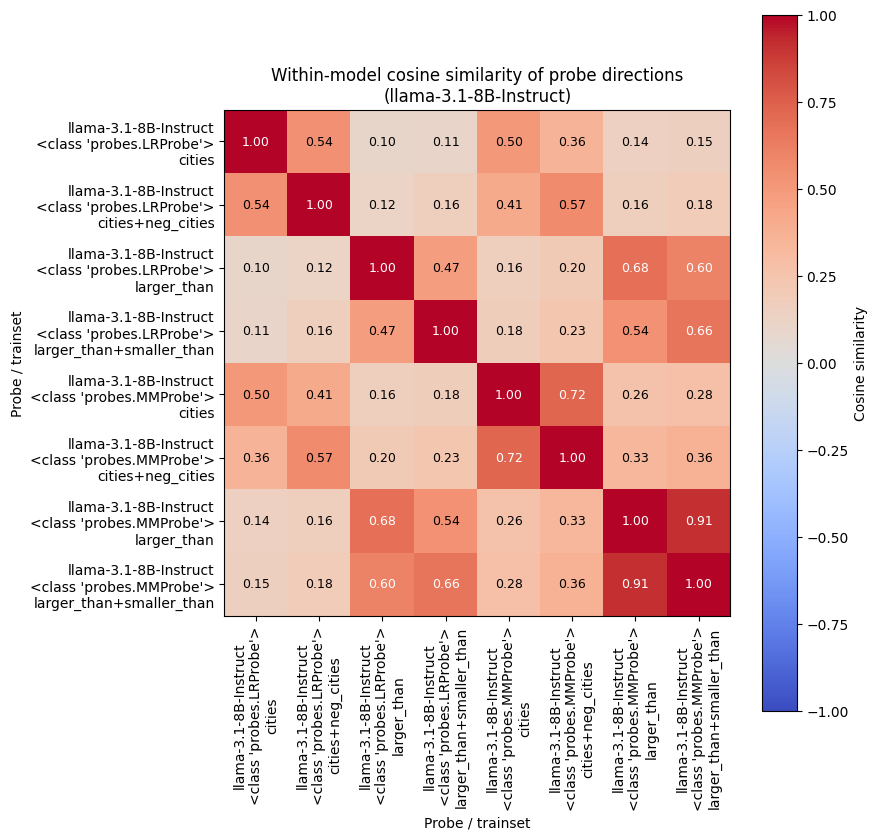

In [15]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
model_name = "llama-3.1-8B-Instruct"

# -----------------------------
# FLATTEN DIRECTIONS (ONE MODEL)
# -----------------------------
rows = []

for probe_name, medley_dict in probe_directions[model_name].items():
    for trainset, direction in medley_dict.items():
        if direction is None:
            continue
        direction = direction.detach().cpu()
        direction = direction / direction.norm()
        rows.append({
            "probe": probe_name,
            "trainset": trainset,
            "direction": direction,
        })

df = pd.DataFrame(rows).reset_index(drop=True)

labels = [
    f"{model_name}\n{r.probe}\n{r.trainset}"
    for r in df.itertuples()
]

# -----------------------------
# BUILD COSINE SIM MATRIX
# -----------------------------
N = len(df)
sim = np.zeros((N, N))

for i, a in enumerate(df.itertuples()):
    for j, b in enumerate(df.itertuples()):
        sim[i, j] = torch.dot(a.direction, b.direction).item()

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(
    figsize=(1.1 * N, 1.1 * N)
)

im = ax.imshow(
    sim,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="equal",
)

# Axis labels
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_xlabel("Probe / trainset")
ax.set_ylabel("Probe / trainset")
ax.set_title(f"Within-model cosine similarity of probe directions\n({model_name})")

# -----------------------------
# ADD NUMERIC ANNOTATIONS
# -----------------------------
for i in range(N):
    for j in range(N):
        val = sim[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="black" if abs(val) < 0.6 else "white",
            fontsize=9,
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()
plt.show()
